In [4]:
import pandas as pd
import random

In [5]:
L = []
for i in range(10000):
    a = random.randint(1,6)
    b = random.randint(1,6)
    L.append(a+b)

L[:5]


[7, 7, 7, 6, 6]

In [6]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

<Axes: >

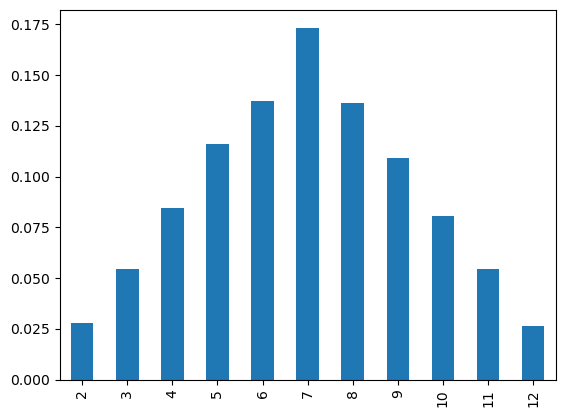

In [7]:
s.plot(kind='bar')

<Axes: >

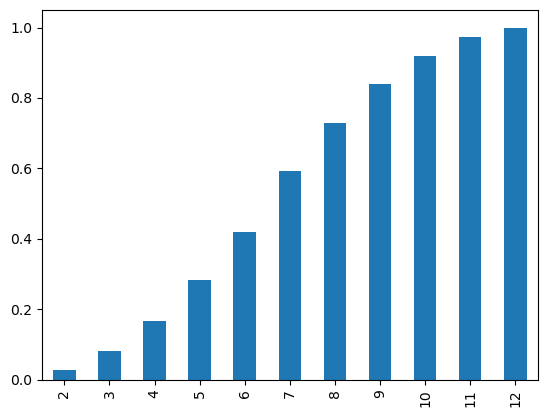

In [8]:
s.cumsum().plot(kind='bar')

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal
sample = normal(loc=50,scale=5,size=1000)

In [10]:
sample_mean =sample.mean()

In [11]:
sample_std = sample.std()

(array([  1.,   1.,   2.,  12.,  17.,  38.,  57.,  92., 129., 133., 128.,
        115.,  94.,  85.,  50.,  24.,  12.,   7.,   2.,   1.]),
 array([32.55390802, 34.24768779, 35.94146756, 37.63524733, 39.3290271 ,
        41.02280686, 42.71658663, 44.4103664 , 46.10414617, 47.79792594,
        49.49170571, 51.18548548, 52.87926525, 54.57304502, 56.26682479,
        57.96060455, 59.65438432, 61.34816409, 63.04194386, 64.73572363,
        66.4295034 ]),
 <BarContainer object of 20 artists>)

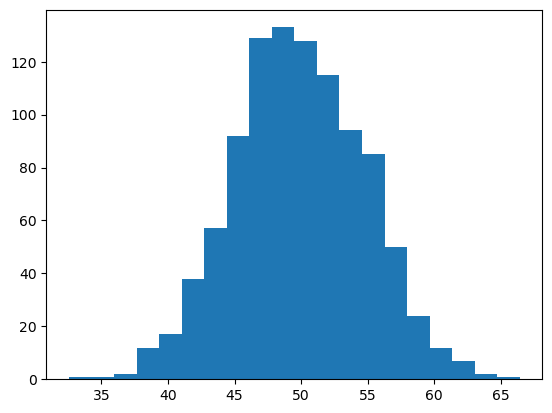

In [12]:
plt.hist(sample,bins=20)

In [13]:
#fit the distribution with the above parameters
from scipy.stats import norm
dist = norm(sample_mean,sample_std)

In [14]:
values = np.linspace(sample.min(),sample.max(),1000)

In [15]:
probabilities = [dist.pdf(x) for x in values]

(array([0.0005904 , 0.0005904 , 0.00118079, 0.00708475, 0.01003672,
        0.02243503, 0.03365255, 0.05431639, 0.07616102, 0.07852261,
        0.07557063, 0.06789549, 0.05549718, 0.05018362, 0.02951978,
        0.01416949, 0.00708475, 0.00413277, 0.00118079, 0.0005904 ]),
 array([32.55390802, 34.24768779, 35.94146756, 37.63524733, 39.3290271 ,
        41.02280686, 42.71658663, 44.4103664 , 46.10414617, 47.79792594,
        49.49170571, 51.18548548, 52.87926525, 54.57304502, 56.26682479,
        57.96060455, 59.65438432, 61.34816409, 63.04194386, 64.73572363,
        66.4295034 ]),
 <BarContainer object of 20 artists>)

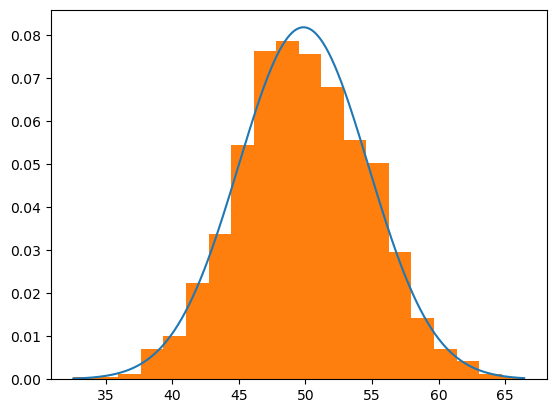

In [16]:
plt.plot(values,probabilities)
plt.hist(sample,bins=20,density=True)

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_66214/2262056078.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

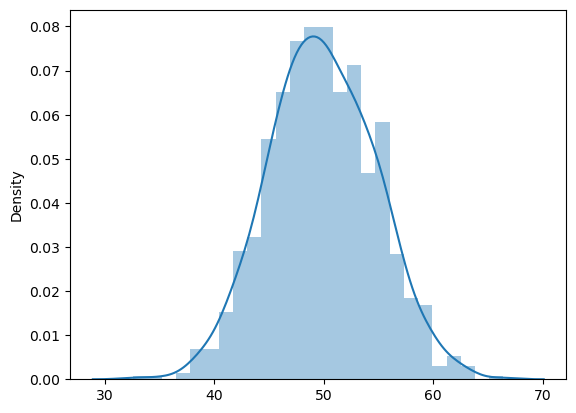

In [17]:
#sns.dist also does the same work
import seaborn as sns
sns.distplot(sample)

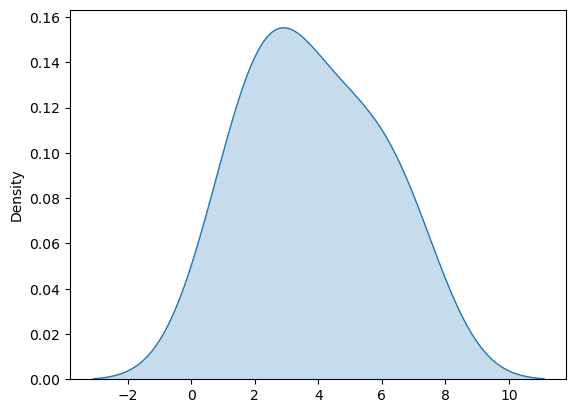

In [18]:
data = [1, 2, 2.5, 3, 4, 5, 6, 7]
sns.kdeplot(data, fill=True)
plt.show()

# KDE

In [19]:
sample1 = normal(loc=20,scale=5,size=300)
sample2 = normal(loc=40,scale=5,size=700)
sampleX = np.hstack((sample1,sample2))

(array([ 1.,  0.,  3.,  3.,  5.,  6., 12., 12., 27., 24., 36., 27., 29.,
        29., 24., 25., 18.,  8., 16., 18., 12., 21., 33., 44., 50., 65.,
        70., 81., 56., 61., 42., 47., 26., 25., 20., 10.,  7.,  4.,  2.,
         1.]),
 array([ 5.7896329 ,  7.04076827,  8.29190364,  9.54303901, 10.79417438,
        12.04530975, 13.29644512, 14.54758049, 15.79871586, 17.04985123,
        18.3009866 , 19.55212197, 20.80325734, 22.05439271, 23.30552808,
        24.55666345, 25.80779881, 27.05893418, 28.31006955, 29.56120492,
        30.81234029, 32.06347566, 33.31461103, 34.5657464 , 35.81688177,
        37.06801714, 38.31915251, 39.57028788, 40.82142325, 42.07255862,
        43.32369399, 44.57482936, 45.82596473, 47.0771001 , 48.32823547,
        49.57937084, 50.83050621, 52.08164157, 53.33277694, 54.58391231,
        55.83504768]),
 <BarContainer object of 40 artists>)

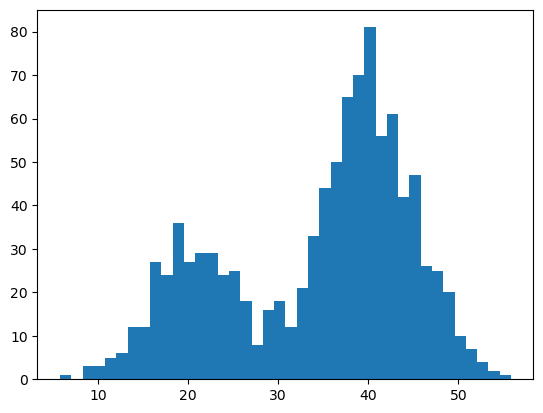

In [20]:
plt.hist(sampleX,bins=40)

In [21]:
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=3)

In [22]:
sampleX = sampleX.reshape(len(sampleX),1)
kde.fit(sampleX)


,bandwidth,3
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [23]:
values_1 = np.linspace(sampleX.min(),sampleX.max(),1000)
values_1 = values_1.reshape(len(values_1),1)

In [24]:
probabilities = kde.score_samples(values_1)
probabilities = np.exp(probabilities)
#The .score_samples() method is commonly used in scikit-learn models (especially in density estimation models) to return the log of the probability density function (log PDF) evaluated at given samples.
#thats why we use exponential function to cancel it out

<Axes: ylabel='Density'>

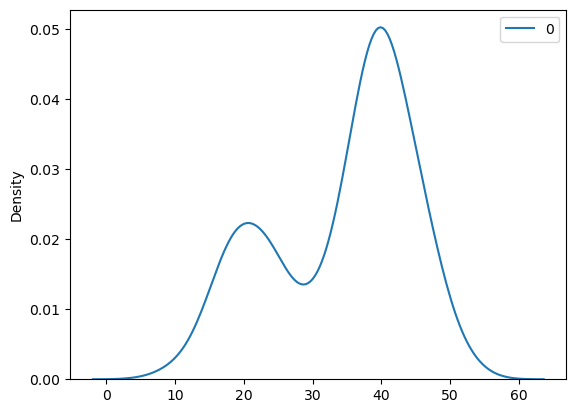

In [25]:
import seaborn as sns
sns.kdeplot(sampleX)


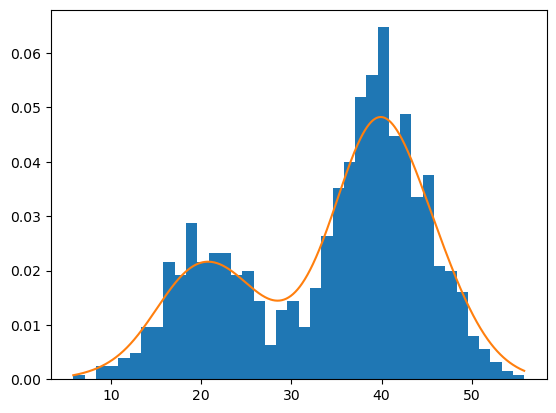

In [26]:
plt.hist(sampleX,bins=40,density=True)
plt.plot(values_1,probabilities)

# 2 D plot

In [27]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

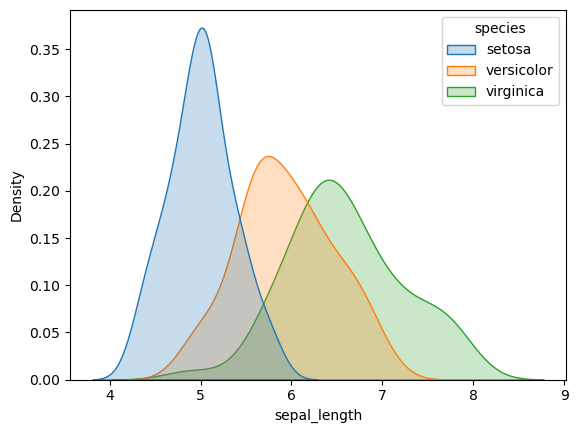

In [29]:
sns.kdeplot(data = df, x='sepal_length', hue='species', fill=True)

<Axes: xlabel='sepal_length', ylabel='sepal_length'>

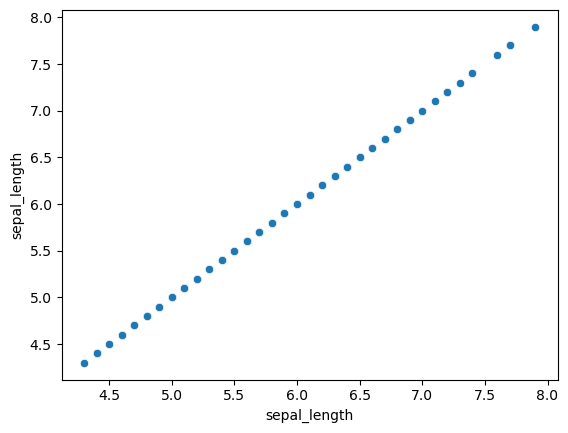

In [30]:
import seaborn as sns

sns.scatterplot(data=df, x='sepal_length', y='sepal_length')
# Actually, use scipy's version above - it's cleaner for Q-Q

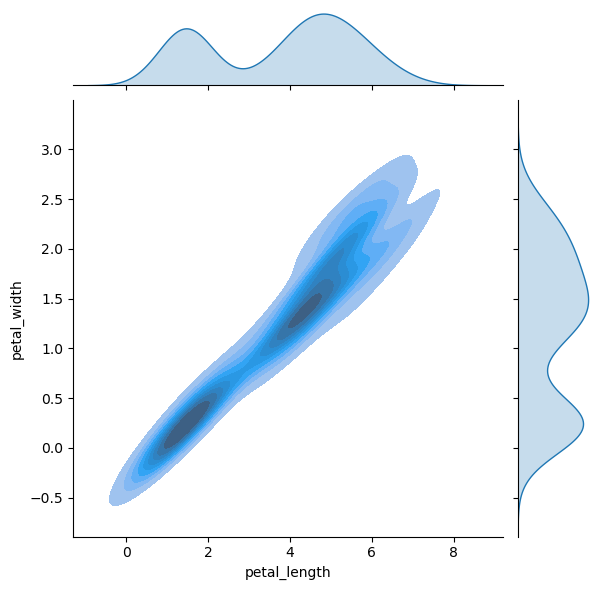

In [31]:
sns.jointplot(x='petal_length',y='petal_width',data=df,kind='kde',fill=True)

In [32]:
iris = sns.load_dataset('iris')

# QQ PLOT

In [33]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

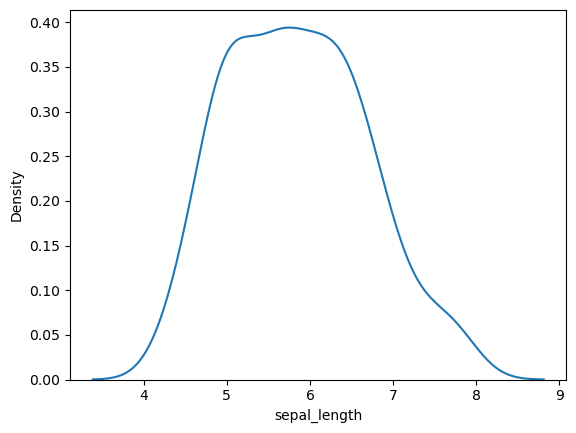

In [34]:
sns.kdeplot(iris['sepal_length'])

In [35]:
temp = sorted(iris['sepal_length'].to_list())

In [36]:
y_quant = []
for i in range(1,101):
    y_quant.append(np.percentile(temp,i))

In [37]:
samples = np.random.normal(loc=0,scale=1,size=1000)


In [38]:
x_quant = []
for i in range(1,101):
    x_quant.append(np.percentile(samples,i))

<Axes: >

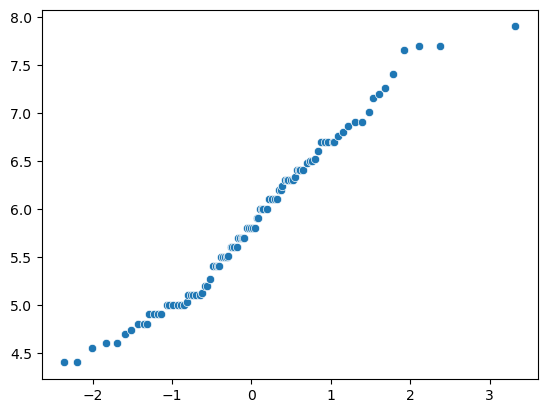

In [39]:
sns.scatterplot(x=x_quant,y=y_quant)

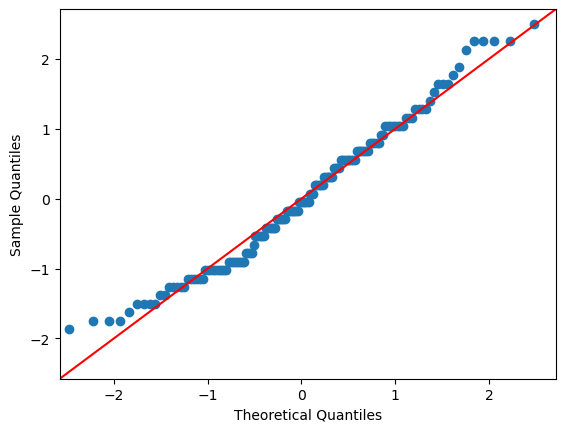

In [40]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig = sm.qqplot(iris['sepal_length'],line='45',fit=True)
plt.show()


# Pareto Distribution

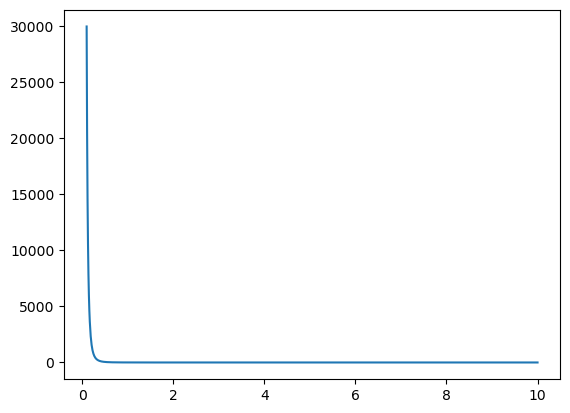

In [41]:
import numpy as np 
import matplotlib.pyplot as plt
#define the parameters for pareto distribution
alpha = 3
xm = 1

#create an array of x values
x = np.linspace(0.1,10,1000)

#calculate the pdf
y = alpha * (xm**alpha) / (x**(alpha+1))
#plot the pdf
plt.plot(x,y)
plt.show()



if the log graph is a straight line then it is supposed to be a pareto 

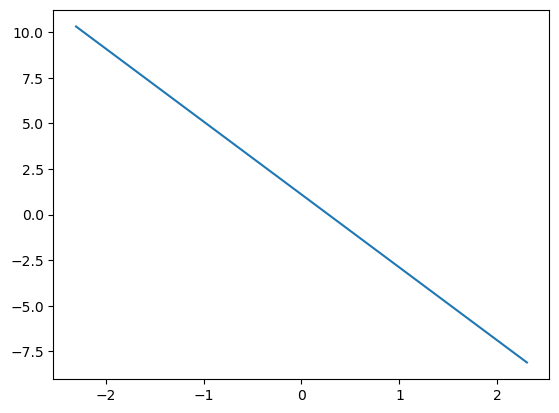

In [42]:
plt.plot(np.log(x),np.log(y))
plt.show()

# ploting a qq plot


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [44]:
# Example: Normal data
data = np.random.normal(loc=0, scale=1, size=1000)


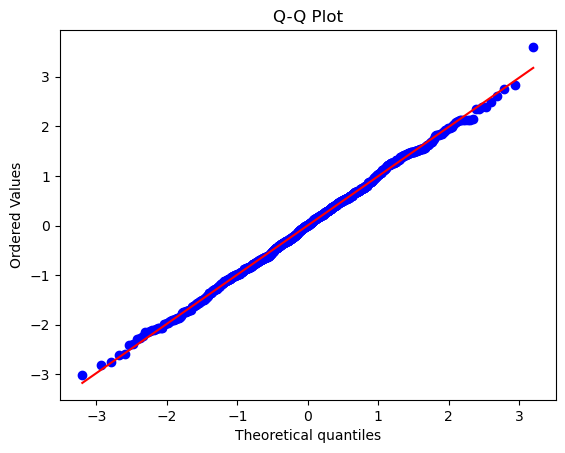

In [45]:
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()
